In [1]:
!pip install transformers[torch] pandas scikit-learn seaborn matplotlib -q

In [2]:
import pandas as pd
import numpy as np
import random
import torch
import os
import time
import warnings
import json
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModel,
    #AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    #EarlyStoppingCallback
)
import torch.nn as nn
from google.colab import files
from collections import Counter
import sys
import shutil

warnings.filterwarnings('ignore')

In [3]:
SEED = 42
NUM_LABELS = 2

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"{SEED}")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

42
Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA Available: True
GPU: Tesla T4


In [4]:
print("Upload Train Dataset")
uploaded_train = files.upload()
train_file = list(uploaded_train.keys())[0]

Upload Train Dataset


Saving originalDS1146.csv to originalDS1146.csv


In [5]:
print("Upload Test Dataset")
uploaded_test = files.upload()
test_file = list(uploaded_test.keys())[0]

Upload Test Dataset


Saving test.csv to test.csv


In [7]:
train_df = pd.read_csv(train_file, encoding='utf-8', header=None, names=['text', 'label'])
test_df = pd.read_csv(test_file, encoding='utf-8', header=None, names=['text', 'label'])

print(f"- Train Data: {len(train_df)} ")
print(f"- Test Data: {len(test_df)} ")

- Train Data: 6707 
- Test Data: 1854 


In [8]:
def clean_data(df):
    df = df.copy()
    df['text'] = df['text'].astype(str).str.strip()
    df = df[df['text'].str.len() > 3]
    return df

train_df = clean_data(train_df)
test_df = clean_data(test_df)

print(f"- Train Data: {len(train_df)} ")
print(f"- Test Data: {len(test_df)} ")

- Train Data: 6707 
- Test Data: 1854 


In [9]:
# ****************** Transform to Binary ***************************

print("Initial distribution of labels in training data:")
print(train_df['label'].value_counts().sort_index())
print("\n Initial distribution of labels in Test data:")
print(test_df['label'].value_counts().sort_index())

# Deleting Data with Label "0"
train_df = train_df[train_df['label'] != 0]
test_df = test_df[test_df['label'] != 0]

# Positive labels (+1 and +2) to "1" and negative labels (-1 and -2) to "0"
train_df['label'] = train_df['label'].apply(lambda x: 1 if x > 0 else 0)
test_df['label'] = test_df['label'].apply(lambda x: 1 if x > 0 else 0)

print("\n Done")

Initial distribution of labels in training data:
label
-2      34
-1     619
 0    2905
 1    1958
 2    1191
Name: count, dtype: int64

 Initial distribution of labels in Test data:
label
-2     12
-1    184
 0    743
 1    561
 2    354
Name: count, dtype: int64

 Done


In [10]:
print("Final distribution of labels in training data:")
print(train_df['label'].value_counts())
print(f"\n {train_df['label'].value_counts(normalize=True).round(3).to_dict()}")

print("\n Final distribution of labels in Test data:")
print(test_df['label'].value_counts())
print(f"\n {test_df['label'].value_counts(normalize=True).round(3).to_dict()}")

X_train_full = train_df['text'].tolist()
y_train_full = train_df['label'].tolist()
X_test = test_df['text'].tolist()
y_test = test_df['label'].tolist()

Final distribution of labels in training data:
label
1    3149
0     653
Name: count, dtype: int64

 {1: 0.828, 0: 0.172}

 Final distribution of labels in Test data:
label
1    915
0    196
Name: count, dtype: int64

 {1: 0.824, 0: 0.176}


In [11]:
# ****************** Data Split to Train/Validation ***********************

print(f"\n Data Split to Train/Validation (seed={SEED})")
print("*Note*: Test set is already separate (uploaded file)!!!")

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_full
)

print(f"Final Split:")
print(f"• Train: {len(X_train)}  ({len(X_train)/len(X_train_full)*100:.1f}%)")
print(f"• Validation: {len(X_val)}  ({len(X_val)/len(X_train_full)*100:.1f}%)")
print(f"• Test: {len(X_test)} ")


 Data Split to Train/Validation (seed=42)
*Note*: Test set is already separate (uploaded file)!!!
Final Split:
• Train: 3231  (85.0%)
• Validation: 571  (15.0%)
• Test: 1111 


In [12]:
class EmbeddingClassifier(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Linear(
            self.encoder.config.hidden_size, num_labels
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        # Mean Pooling (For embedding models)
        pooled_output = outputs.last_hidden_state.mean(dim=1)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        return {
            "loss": loss,
            "logits": logits
        }

In [13]:
# ****************** Model and Tokenizer ***************

# ##### Model Selection (Uncomment a Model) ########


MODEL_NAME = "agentlans/multilingual-e5-small-aligned-sentiment"     # E5_Small

#MODEL_NAME = "Ludo33/e5_Sentiment_General_v2"                         # E5_General

#MODEL_NAME = "Alibaba-NLP/gte-multilingual-base"       #GTE

#MODEL_NAME = "Alibaba-NLP/gte-multilingual-reranker-base"   #GTE_Reranker



print(f"\n Selected Model: {MODEL_NAME}")

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    print(f"Done!")
except Exception as e:
    print(f"Error!!! {e}")
    tokenizer = AutoTokenizer.from_pretrained("agentlans/multilingual-e5-small-aligned-sentiment")

def tokenize_function(texts):
    texts = ["query: " + t for t in texts]
    return tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=128,
        #max_length=64,
        return_tensors="pt"
    )

train_encodings = tokenize_function(X_train)
val_encodings = tokenize_function(X_val)
test_encodings = tokenize_function(X_test)


 Selected Model: agentlans/multilingual-e5-small-aligned-sentiment


config.json:   0%|          | 0.00/864 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Done!


In [17]:
class PersianSentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = PersianSentimentDataset(train_encodings, y_train)
val_dataset = PersianSentimentDataset(val_encodings, y_val)
test_dataset = PersianSentimentDataset(test_encodings, y_test)

In [18]:
# *************** Metrics **************

def compute_metrics(p):
    predictions = p.predictions.argmax(-1)
    labels = p.label_ids

    accuracy = accuracy_score(labels, predictions)
    f1_weighted = f1_score(labels, predictions, average='weighted')
    f1_binary = f1_score(labels, predictions, average='binary', pos_label=1)

    return {
        'accuracy': accuracy,
        'f1_weighted': f1_weighted,
        'f1_binary': f1_binary,
    }

In [19]:
# ********************  Hyperparameters  **********************


HYPERPARAM_COMBINATIONS = [
    {'lr': 2e-5, 'batch_size': 8, 'epochs': 3},
    {'lr': 3e-5, 'batch_size': 16, 'epochs': 3},
    {'lr': 5e-5, 'batch_size': 16, 'epochs': 3},
    {'lr': 2e-5, 'batch_size': 32, 'epochs': 3},
    {'lr': 5e-5, 'batch_size': 32, 'epochs': 3},
    #{'lr': 5e-5, 'batch_size': 8, 'epochs': 3},

]

results = []
best_val_accuracy = 0
best_model_checkpoint_path = None
best_hyperparams = None
best_combination_id = None

os.makedirs("./hyperparameter_search", exist_ok=True)

for idx, hp in enumerate(HYPERPARAM_COMBINATIONS, 1):
    print(f"\n{'='*60}")
    print(f"Combination {idx}/{len(HYPERPARAM_COMBINATIONS)}")
    print(f"{'='*60}")
    print(f"   • Learning Rate: {hp['lr']:.0e}")
    print(f"   • Batch Size: {hp['batch_size']}")
    print(f"   • Epochs: {hp['epochs']}")

    start_time = time.time()

    try:
        timestamp = int(time.time())
        combination_output_dir = f"./hyperparameter_search/combination_{idx}_{timestamp}"
        os.makedirs(combination_output_dir, exist_ok=True)

        model = EmbeddingClassifier(
           model_name=MODEL_NAME,
           num_labels=NUM_LABELS
        )

        import transformers
        TRANSFORMERS_VERSION = transformers.__version__

        if hasattr(TrainingArguments, 'evaluation_strategy'):
            eval_strat_param = 'evaluation_strategy'
            save_strat_param = 'save_strategy'
        else:
            eval_strat_param = 'eval_strategy'
            save_strat_param = 'save_strategy'

        # Training Settings
        training_args_dict = {
            'output_dir': combination_output_dir,
            'num_train_epochs': hp['epochs'],
            'per_device_train_batch_size': hp['batch_size'],
            'per_device_eval_batch_size': hp['batch_size'],
            'learning_rate': hp['lr'],
            'warmup_ratio': 0.1,
            'weight_decay': 0.01,
            'logging_dir': f'./logs/combination_{idx}',
            'logging_steps': 50,
            eval_strat_param: "epoch",
            save_strat_param: "epoch",
            'load_best_model_at_end': True,
            'metric_for_best_model': "eval_accuracy",
            'greater_is_better': True,
            'save_total_limit': 1,
            'fp16': torch.cuda.is_available(),
            'report_to': "none",
            'seed': SEED,
            'dataloader_drop_last': False,
            'remove_unused_columns': True,
            'label_names': ["labels"]
        }

        training_args = TrainingArguments(**training_args_dict)

        # Trainer
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            compute_metrics=compute_metrics,
            #callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )

        train_result = trainer.train()

        print("Evaluate on Validation Set...")
        val_metrics = trainer.evaluate(val_dataset)

        training_time = time.time() - start_time

        result = {
            'combination_id': idx,
            'learning_rate': hp['lr'],
            'batch_size': hp['batch_size'],
            'epochs': hp['epochs'],
            'val_accuracy': val_metrics['eval_accuracy'],
            'val_f1_weighted': val_metrics['eval_f1_weighted'],
            'val_f1_binary': val_metrics['eval_f1_binary'],
            'training_loss': train_result.training_loss,
            'training_time_seconds': training_time,
            'training_time_minutes': training_time / 60,
            'model_checkpoint': combination_output_dir,
            'timestamp': timestamp
        }

        results.append(result)

        print(f"\n  Validation Results:")
        print(f"   {'─' * 40}")
        print(f"   • Accuracy: {val_metrics['eval_accuracy']*100:.2f}%")
        print(f"   • F1-Weighted: {val_metrics['eval_f1_weighted']*100:.2f}%")
        print(f"   • F1-Binary: {val_metrics['eval_f1_binary']*100:.2f}%")
        print(f"   • Training Loss: {train_result.training_loss:.4f}")
        print(f"   • Training Time: {training_time/60:.1f} min")

        # Best Model
        if val_metrics['eval_accuracy'] > best_val_accuracy:
            best_val_accuracy = val_metrics['eval_accuracy']
            best_model_checkpoint_path = combination_output_dir
            best_hyperparams = hp.copy()
            best_combination_id = idx

            print(f"\n  !!!NEW BEST MODEL!!!")
            print(f"  Accuracy Improved: {best_val_accuracy*100:.2f}%")
            print(f"   Best model path checkpoint: {best_model_checkpoint_path}")

        del model
        del trainer
        torch.cuda.empty_cache() if torch.cuda.is_available() else None

    except Exception as e:
        print(f"\n   ERROR!!! {idx}: {str(e)}")
        import traceback
        traceback.print_exc()

        error_result = {
            'combination_id': idx,
            'learning_rate': hp['lr'],
            'batch_size': hp['batch_size'],
            'epochs': hp['epochs'],
            'error': str(e),
            'val_accuracy': 0.0,
            'training_time_seconds': time.time() - start_time
        }
        results.append(error_result)
        continue


Combination 1/5
   • Learning Rate: 2e-05
   • Batch Size: 8
   • Epochs: 3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: agentlans/multilingual-e5-small-aligned-sentiment
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Binary
1,0.252964,0.183208,0.935201,0.935332,0.960847
2,0.176209,0.182384,0.940455,0.939166,0.964435
3,0.167442,0.188869,0.942207,0.941602,0.965300


Evaluate on Validation Set...


...

[transformers] BertModel LOAD REPORT from: agentlans/multilingual-e5-small-aligned-sentiment
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Binary
1,0.215360,0.159424,0.935201,0.933022,0.961498
2,0.133735,0.133912,0.956217,0.955167,0.973877
3,0.087891,0.152306,0.952715,0.952618,0.971489


Evaluate on Validation Set...


Training Loss,Validation Loss,Epoch,Accuracy,F1 Weighted,F1 Binary
0.087891,0.133912,3,0.956217,0.955167,0.973877



  Validation Results:
   ────────────────────────────────────────
   • Accuracy: 95.62%
   • F1-Weighted: 95.52%
   • F1-Binary: 97.39%
   • Training Loss: 0.1810
   • Training Time: 1.7 min


In [20]:
# ******************** Results Analysis **********************

results_df = pd.DataFrame(results)

valid_results = results_df[results_df['val_accuracy'] > 0]

if len(valid_results) > 0:
    valid_results = valid_results.sort_values('val_accuracy', ascending=False)

    print(f"Best Validation Accuracy: {valid_results.iloc[0]['val_accuracy']*100:.2f}%")

    print("\n" + "="*70)
    print("Ranking of combinations based on Validation")
    print("="*70)

    for i, (_, row) in enumerate(valid_results.iterrows(), 1):
        print(f"\n{i}. Combination #{int(row['combination_id'])}")
        print(f"   • LR={row['learning_rate']:.0e}, BS={int(row['batch_size'])}, Epochs={int(row['epochs'])}")
        print(f"   • Accuracy: {row['val_accuracy']*100:.2f}%")
        print(f"   • F1-Binary: {row['val_f1_binary']*100:.2f}%")
        print(f"   • Time: {row['training_time_minutes']:.1f} min")

    # Best Combination
    best_row = valid_results.iloc[0]
    print(f"• Combination ID: #{int(best_row['combination_id'])}")
    print(f"• Learning Rate: {best_row['learning_rate']:.0e}")
    print(f"• Batch Size: {best_row['batch_size']}")
    print(f"• Epochs: {best_row['epochs']}")
    print(f"• Validation Accuracy: {best_row['val_accuracy']*100:.2f}%")
    print(f"• Validation F1-Binary: {best_row['val_f1_binary']*100:.2f}%")
    print(f"• Training Time : {best_row['training_time_minutes']:.1f} min")
    print(f"• Checkpoint Path: {best_model_checkpoint_path}")
else:
    print("ERROR")
    best_model_checkpoint_path = None

Best Validation Accuracy: 95.62%

Ranking of combinations based on Validation

1. Combination #3
   • LR=5e-05, BS=16, Epochs=3
   • Accuracy: 95.62%
   • F1-Binary: 97.40%
   • Time: 3.1 min

2. Combination #5
   • LR=5e-05, BS=32, Epochs=3
   • Accuracy: 95.62%
   • F1-Binary: 97.39%
   • Time: 1.7 min

3. Combination #4
   • LR=2e-05, BS=32, Epochs=3
   • Accuracy: 95.45%
   • F1-Binary: 97.27%
   • Time: 1.2 min

4. Combination #2
   • LR=3e-05, BS=16, Epochs=3
   • Accuracy: 94.92%
   • F1-Binary: 96.96%
   • Time: 3.9 min

5. Combination #1
   • LR=2e-05, BS=8, Epochs=3
   • Accuracy: 94.22%
   • F1-Binary: 96.53%
   • Time: 3.6 min
• Combination ID: #3
• Learning Rate: 5e-05
• Batch Size: 16
• Epochs: 3
• Validation Accuracy: 95.62%
• Validation F1-Binary: 97.40%
• Training Time : 3.1 min
• Checkpoint Path: ./hyperparameter_search/combination_3_1786655302


In [21]:
# ****************** Retraining with the Best Parameters ====================


if best_hyperparams and len(valid_results) > 0:
    print(f"Best Parameters:")
    print(f"   • Learning Rate: {best_hyperparams['lr']:.0e}")
    print(f"   • Batch Size: {best_hyperparams['batch_size']}")
    print(f"   • Epochs: {best_hyperparams['epochs']}")

    print("\n Cobination of Train + Validation for the Final Training...")
    X_train_final = X_train + X_val
    y_train_final = y_train + y_val

    train_final_encodings = tokenize_function(X_train_final)
    train_final_dataset = PersianSentimentDataset(train_final_encodings, y_train_final)

    final_model = EmbeddingClassifier(
        model_name=MODEL_NAME,
        num_labels=NUM_LABELS
      )

    import transformers
    if hasattr(TrainingArguments, 'evaluation_strategy'):
        eval_strat_param = 'evaluation_strategy'
    else:
        eval_strat_param = 'eval_strategy'

    # Final Training Settings
    final_args_dict = {
        'output_dir': './final_model_training',
        'num_train_epochs': best_hyperparams['epochs'],
        'per_device_train_batch_size': best_hyperparams['batch_size'],
        'per_device_eval_batch_size': best_hyperparams['batch_size'],
        'learning_rate': best_hyperparams['lr'],
        'warmup_ratio': 0.1,
        'weight_decay': 0.01,
        'logging_dir': './logs/final_training',
        'logging_steps': 50,
        eval_strat_param: "no",
        'save_strategy': "no",
        'fp16': torch.cuda.is_available(),
        'report_to': "none",
        'seed': SEED,
        'dataloader_drop_last': False,
        'remove_unused_columns': True,
        'label_names': ["labels"],
        'load_best_model_at_end': False
    }

    final_args = TrainingArguments(**final_args_dict)

    final_trainer = Trainer(
        model=final_model,
        args=final_args,
        train_dataset=train_final_dataset,
        compute_metrics=compute_metrics
    )

    print("Retraining......")
    start_time = time.time()
    final_trainer.train()
    training_time = time.time() - start_time

    print(f"Done!({training_time/60:.1f} min)")

    final_model_dir = "./final_trained_model"
    final_trainer.save_model(final_model_dir)
    tokenizer.save_pretrained(final_model_dir)

    best_model = final_model
    best_trainer = final_trainer

else:
    print("ERROR!!!")
    best_model = None
    best_trainer = None

Best Parameters:
   • Learning Rate: 5e-05
   • Batch Size: 16
   • Epochs: 3

 Cobination of Train + Validation for the Final Training...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: agentlans/multilingual-e5-small-aligned-sentiment
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Retraining......


Step,Training Loss
50,0.490229
100,0.268306
150,0.225419
200,0.199220
250,0.181093
300,0.139847
350,0.151809
400,0.133005
450,0.123101
500,0.115468


Done!(0.8 min)



 Final Results on Test Set:
• Accuracy: 92.80%
• F1-Score (Weighted): 92.76%
• F1-Score (Binary): 95.64%

 Report:
               precision    recall  f1-score   support

Class 0 (Neg)      0.805     0.781     0.793       196
Class 1 (Pos)      0.953     0.960     0.956       915

     accuracy                          0.928      1111
    macro avg      0.879     0.870     0.875      1111
 weighted avg      0.927     0.928     0.928      1111



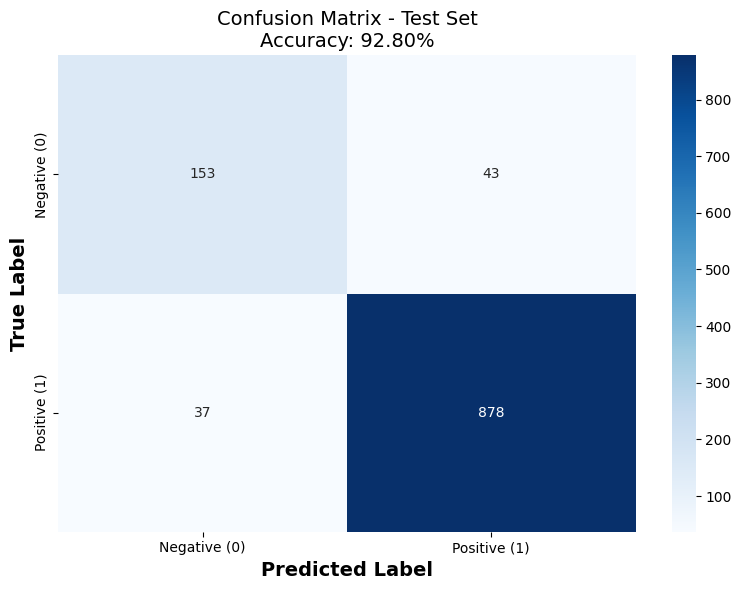

In [22]:
# ************ Final Evaluation on Test Set ******************

if best_trainer is not None:

    try:
        test_predictions = best_trainer.predict(test_dataset)

        test_preds = test_predictions.predictions.argmax(-1)

        test_accuracy = accuracy_score(y_test, test_preds)
        test_f1_weighted = f1_score(y_test, test_preds, average='weighted')
        test_f1_binary = f1_score(y_test, test_preds, average='binary', pos_label=1)

        print(f"\n Final Results on Test Set:")
        print(f"• Accuracy: {test_accuracy*100:.2f}%")
        print(f"• F1-Score (Weighted): {test_f1_weighted*100:.2f}%")
        print(f"• F1-Score (Binary): {test_f1_binary*100:.2f}%")

        print("\n Report:")
        print(classification_report(y_test, test_preds,
                                   target_names=['Class 0 (Neg)', 'Class 1 (Pos)'],
                                   digits=3))

        cm = confusion_matrix(y_test, test_preds)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Negative (0)', 'Positive (1)'],
                    yticklabels=['Negative (0)', 'Positive (1)'])
        plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
        plt.ylabel('True Label', fontsize=14, fontweight='bold')
        plt.title(f'Confusion Matrix - Test Set\nAccuracy: {test_accuracy*100:.2f}%', fontsize=14)
        plt.tight_layout()
        plt.show()

        best_model_info = {
            'model_name': MODEL_NAME,
            'combination_id': best_combination_id,
            'hyperparameters': best_hyperparams,
            'validation_accuracy': float(best_val_accuracy),
            'test_accuracy': float(test_accuracy),
            'test_f1_weighted': float(test_f1_weighted),
            'test_f1_binary': float(test_f1_binary),
            'final_model_path': final_model_dir if 'final_model_dir' in locals() else None
        }

    except Exception as e:
        print(f"ERROR!!!: {str(e)}")
        import traceback
        traceback.print_exc()
        test_accuracy = 0
        test_f1_weighted = 0
        test_f1_binary = 0

else:
    print("ERROR!!!")
    test_accuracy = 0
    test_f1_weighted = 0
    test_f1_binary = 0